# Week 2: Two-View 3D Reconstruction

This notebook implements the second milestone of the CS436 project.
Building on the feature matches from Week 1, we will now:
1. Estimate the **Intrinsic Matrix (K)**.
2. Compute the **Essential Matrix (E)** and **Recover Pose (R, t)**.
3. **Triangulate** the 2D matches into a sparse 3D Point Cloud.
4. Visualize the result in both 2D and 3D.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
import os
import sys

# Add src to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.feature_matching import find_and_filter_matches
from src.reconstruction import (
    get_intrinsic_matrix,
    get_points_from_matches,
    reconstruct_two_views,
    save_ply,
    create_point_cloud
)

In [4]:
# -- 1. Load Images --
IMG_NAME_1 = 'photo6.jpeg'  
IMG_NAME_2 = 'photo7.jpeg'

data_dir = os.path.join(module_path, 'data2')
img1 = cv2.imread(os.path.join(data_dir, IMG_NAME_1))
img2 = cv2.imread(os.path.join(data_dir, IMG_NAME_2))

# Convert to RGB for visualization
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

print(f"Loaded {IMG_NAME_1} and {IMG_NAME_2}")

Loaded photo6.jpeg and photo7.jpeg


In [5]:
# -- 2. Get Feature Matches (Week 1 Code) --
matches, kp1, kp2, match_viz = find_and_filter_matches(img1, img2, lowe_ratio=0.75)

# Convert KeyMatch objects to Nx2 numpy arrays
pts1, pts2 = get_points_from_matches(matches, kp1, kp2)

print(f"Using {len(pts1)} matched points for reconstruction.")

Found 1677 keypoints in img1 and 1464 in img2.
Found 1677 initial matches.
Filtered down to 412 good matches using Lowe's ratio test.
Using 412 matched points for reconstruction.


In [6]:
# -- 3. Reconstruction Pipeline --

# A. Get Intrinsic Matrix (Approximation)
K = get_intrinsic_matrix(img1.shape)
print("Intrinsic Matrix K:\n", K)

# B. Recover Pose and Triangulate
# UPDATED: We now get 'pts1_inliers' back from the function
points_3d, R, t, pts1_inliers = reconstruct_two_views(pts1, pts2, K)

print(f"\nReconstructed {len(points_3d)} 3D points.")
print("Rotation R:\n", R)
print("Translation t:\n", t)

Intrinsic Matrix K:
 [[1.28e+03 0.00e+00 6.40e+02]
 [0.00e+00 1.28e+03 4.80e+02]
 [0.00e+00 0.00e+00 1.00e+00]]
Essential Matrix found. Inliers: 275 / 412

Reconstructed 275 3D points.
Rotation R:
 [[ 0.81893137  0.08154362 -0.5680687 ]
 [-0.05943333  0.99658204  0.05737527]
 [ 0.57080565 -0.01322419  0.82097871]]
Translation t:
 [[ 0.95386341]
 [-0.11016424]
 [ 0.27929989]]


In [7]:
# -- 4. Data Processing for Visualization --

# We want to color the 3D points based on their color in the original image
# UPDATED: We use 'pts1_inliers' here, which matches the length of points_3d
colors = []
for pt in pts1_inliers:
    x, y = int(pt[0]), int(pt[1])
    # Ensure coordinates are within bounds
    if 0 <= y < img1_rgb.shape[0] and 0 <= x < img1_rgb.shape[1]:
        colors.append(img1_rgb[y, x] / 255.0) # Open3D wants 0-1 range
    else:
        colors.append([0, 0, 0])
        
colors = np.array(colors)

# Filter out crazy outliers for better visualization
mean = np.mean(points_3d, axis=0)
std = np.std(points_3d, axis=0)
mask = (np.abs(points_3d - mean) < 3 * std).all(axis=1)

clean_points = points_3d[mask]
clean_colors = colors[mask]

print(f"Filtered {len(points_3d) - len(clean_points)} outliers.")

Filtered 6 outliers.


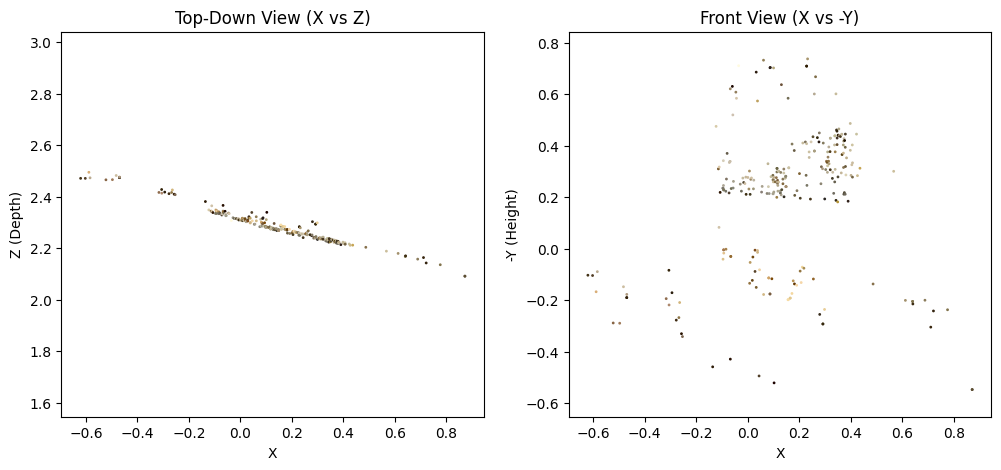

In [8]:
# -- 5. Deliverable: 2D Scatter Plot --
# The TA asked for a "2D scatter plot of your 3D point cloud"
# This usually means plotting X vs Z (Top-down view) or X vs Y (Front view)

plt.figure(figsize=(12, 5))

# Top-Down View (X and Z)
plt.subplot(1, 2, 1)
plt.scatter(clean_points[:, 0], clean_points[:, 2], s=1, c=clean_colors)
plt.title("Top-Down View (X vs Z)")
plt.xlabel("X")
plt.ylabel("Z (Depth)")
plt.axis('equal')

# Front View (X and Y)
# Note: Y is often inverted in computer vision (down is positive)
plt.subplot(1, 2, 2)
plt.scatter(clean_points[:, 0], -clean_points[:, 1], s=1, c=clean_colors)
plt.title("Front View (X vs -Y)")
plt.xlabel("X")
plt.ylabel("-Y (Height)")
plt.axis('equal')

plt.show()

In [9]:
# -- 6. Deliverable: 3D Visualization & Saving --

# Create the Point Cloud object
pcd = create_point_cloud(clean_points, clean_colors)

# Save to .ply
output_file = "reconstruction_output.ply"
o3d.io.write_point_cloud(output_file, pcd)
print(f"Saved {output_file}. You can open this in MeshLab or Open3D viewer.")

# Visualize
# NOTE: This will open a POP-UP window.
# You interact with it using your mouse. Close the window to finish the cell.
print("Opening 3D Visualization window... (Check your taskbar if it doesn't pop up)")
o3d.visualization.draw_geometries([pcd], window_name="Week 2 Reconstruction")

Saved reconstruction_output.ply. You can open this in MeshLab or Open3D viewer.
Opening 3D Visualization window... (Check your taskbar if it doesn't pop up)
